# JOCELYNE GONZÁLEZ HERNÁNDEZ
## 225369-5
### EJERCICIO 2

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv('auto_mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [4]:
#Valores nulo
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [5]:
#Buscar '?'
df[df['horsepower'] == '?'].count()

,0
mpg,6
cylinders,6
displacement,6
horsepower,6
weight,6
acceleration,6
model year,6
origin,6
car name,6


In [50]:
# Convert 'horsepower' to numeric, coercing '?' to NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Calculate the median of the 'horsepower' column
median_horsepower = df['horsepower'].median()

df['horsepower'].fillna(median_horsepower, inplace=True)

df['horsepower'] = df['horsepower'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    int64  
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 28.1+ KB


/tmp/ipython-input-2716663120.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(mean_horsepower, inplace=True)


Una ventaja de los bosques es que no es necesario escalar las varaibles numericas, pero todas deben ser de este tipo. Ya que había valores faltantes fue necesario remplazarlos por la media.

<Axes: >

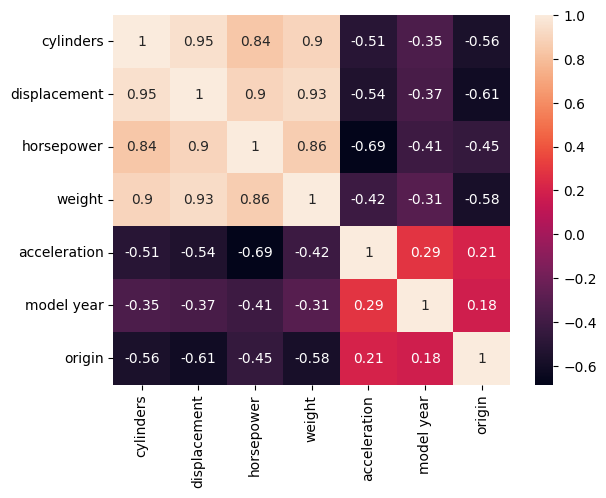

In [13]:
sns.heatmap(df.drop(['mpg', 'car name'], axis=1).corr(), annot=True)

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(['mpg', 'car name'], axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=50, random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [143]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 2.1096227506357628


La elección de los hiperparametros fue ya que son los valores que me dan un mejor RMSE

In [11]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(['mpg', 'car name'], axis=1)
y = df['mpg']

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort and print feature importances
print("Importancia de las variables:\n")
print(feature_importances.sort_values(ascending=False))

Importancia de las variables:

displacement    0.303789
weight          0.222989
cylinders       0.206125
model year      0.127025
horsepower      0.103892
acceleration    0.029280
origin          0.006900
dtype: float64


Eliminé de acuerdo a la importancia de las variables, eliminando solo: acceleration y origin


In [150]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop(['mpg', 'car name', 'acceleration', 'origin'], axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(n_estimators=500, random_state=42)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=500, random_state=42)

In [151]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

RMSE: 2.236226572152292


Una vez ejecutado ambos modelos, con el mismo número de estimaciones (50), puedo decir que el modelo con menos variables empeora, ya que sube el RMSE, pero debido a que no sube tan considerablemente. He escodigo este último como mi modelo final ya que me ahorro dos variables.   
 - RSME (TODAS LAS VARIABLES): RMSE:  2.1096227506357628

 - RSME (QUITANDO 2): 2.159550659280768

In [152]:
new_car_data = pd.DataFrame({
    'cylinders': [4],
    'displacement': [73.6],
    'horsepower': [81],
    'weight': [2348],
    'model year': [112] # 2012 - 1900 = 112
})

# Realizar la predicción
predicted_mpg = regressor.predict(new_car_data)

print(f"El rendimiento predicho para el Chevrolet Spark 2012 es: {predicted_mpg[0]:.2f} mpg")

# Comparar con el rendimiento real
actual_mpg = 40
print(f"El rendimiento real del Chevrolet Spark 2012 es: {actual_mpg} mpg")
print(f"La diferencia entre el rendimiento predicho y el real es: {abs(predicted_mpg[0] - actual_mpg):.2f} mpg")

El rendimiento predicho para el Chevrolet Spark 2012 es: 34.89 mpg
El rendimiento real del Chevrolet Spark 2012 es: 40 mpg
La diferencia entre el rendimiento predicho y el real es: 5.11 mpg
